##Support Vector Regression

##Author -Yashas Samaga




### libraries

In [36]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt

### Import Data Set

In [37]:
df = pd.read_csv("Position_Salaries.csv")
print("Data")
print(df)

x= df.iloc[:,:-1].values
y=df.iloc[:,-1].values

print("Features")

print(x)

print("Dependent Variable")

print(y)
#  leaving the first column as 2nd column is encoded version of the first one
x= df.iloc[:,1:-1].values

print("FInal Features")

print(x)


Data
            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000
Features
[['Business Analyst' 1]
 ['Junior Consultant' 2]
 ['Senior Consultant' 3]
 ['Manager' 4]
 ['Country Manager' 5]
 ['Region Manager' 6]
 ['Partner' 7]
 ['Senior Partner' 8]
 ['C-level' 9]
 ['CEO' 10]]
Dependent Variable
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]
FInal Features
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


### Feature scaling
 for both  feature and dependent variable to bring them to same range

In [38]:
y= y.reshape(-1,1)
print("reshaped dependent variable array")
print(y)

reshaped dependent variable array
[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [39]:
from sklearn import preprocessing
scaler_x = preprocessing.StandardScaler()
x_scaled=scaler_x.fit_transform(x)

print("scaled x")
print(x_scaled)

scalar_y=preprocessing.StandardScaler()
y_scaled=scalar_y.fit_transform(y)
print("scaled y")
print(y_scaled)

scaled x
[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]
scaled y
[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


### Training SVR model

In [40]:
from sklearn import svm
#  SVR model
regr = svm.SVR(kernel='rbf')
regr.fit(x_scaled,y_scaled)

# Training the model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

### predicting new result

In [41]:
reg_predict=regr.predict(scaler_x.transform([[6.5]]))
print(reg_predict)

finalPredictedValue = scalar_y.inverse_transform(reg_predict.reshape(-1,1))

print("finalPredictedValue")
print(finalPredictedValue)


[-0.27861589]
finalPredictedValue
[[170370.0204065]]


### visualization SVR regression results


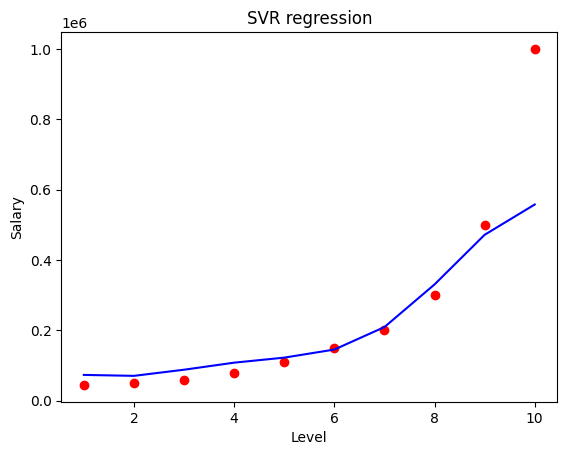

In [42]:
import matplotlib.pyplot as plt
plt.scatter(x, y, color='red')
plt.plot(x, scalar_y.inverse_transform(regr.predict(x_scaled).reshape(-1,1)), color='blue')
plt.title('SVR regression')
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()